# About this Notebook

- Data: https://www.kaggle.com/datasets/coderanand/university-query-priority-classification
- EDA : https://www.kaggle.com/code/rudraprasadbhuyan/quick-eda-university-student-query

# Import

In [66]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.metrics import ConfusionMatrixDisplay


from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [67]:
train_path = r"C:\Users\Rudra\Desktop\kaggle\university-query-priority\university_query_train.csv"
test_path = r"C:\Users\Rudra\Desktop\kaggle\university-query-priority\university_query_test.csv"

In [68]:
train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)

# Info

In [69]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Query_ID          5000 non-null   int64 
 1   Student_Query     5000 non-null   object
 2   Department        5000 non-null   object
 3   Days_To_Deadline  5000 non-null   int64 
 4   Priority_Label    5000 non-null   object
dtypes: int64(2), object(3)
memory usage: 195.4+ KB


In [70]:
train_df = train_df.drop(columns=["Query_ID"])
test_df = test_df.drop(columns=["Query_ID"])

In [71]:
train_df.sample(3)

,Student_Query,Department,Days_To_Deadline,Priority_Label
1582,What are university working hours?,Academic Office,10,Low
2638,LMS is not allowing assignment upload.,Hostel Office,43,Medium
3301,My admit card has incorrect details.,Hostel Office,37,High


# Structure

In [72]:
""" 
Raw Data
   ↓
ColumnTransformer
   ├── TF-IDF (text)
   ├── Scaling (numeric)
   └── OHE (categorical)
   ↓
Logistic Regression
   ↓
Prediction
"""

' \nRaw Data\n   ↓\nColumnTransformer\n   ├── TF-IDF (text)\n   ├── Scaling (numeric)\n   └── OHE (categorical)\n   ↓\nLogistic Regression\n   ↓\nPrediction\n'

# Define Columns

In [73]:
text_col = "Student_Query"
numeric_cols = ["Days_To_Deadline"]
categorical_cols = ["Department"]
target_col = "Priority_Label"

# Preprocessor

In [74]:
preprocessor = ColumnTransformer(
    transformers=[
        ("tfidf", TfidfVectorizer(max_features=5000), text_col),
        ("num", StandardScaler(), numeric_cols),
        ("cat", OneHotEncoder(drop="first"), categorical_cols)
    ]
)

preprocessor

ColumnTransformer(transformers=[('tfidf', TfidfVectorizer(max_features=5000),
                                 'Student_Query'),
                                ('num', StandardScaler(), ['Days_To_Deadline']),
                                ('cat', OneHotEncoder(drop='first'),
                                 ['Department'])])

In [75]:
pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=1000))
])

pipeline

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('tfidf',
                                                  TfidfVectorizer(max_features=5000),
                                                  'Student_Query'),
                                                 ('num', StandardScaler(),
                                                  ['Days_To_Deadline']),
                                                 ('cat',
                                                  OneHotEncoder(drop='first'),
                                                  ['Department'])])),
                ('model', LogisticRegression(max_iter=1000))])

In [76]:
# Split X and y
X_train = train_df.drop(columns=[target_col])
y_train = train_df[target_col]

X_test = test_df.drop(columns=[target_col])
y_test = test_df[target_col]

print(X_train.shape, X_test.shape)
print(y_train.shape, y_test.shape)

(5000, 3) (1000, 3)
(5000,) (1000,)


In [77]:
# Fit
pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('tfidf',
                                                  TfidfVectorizer(max_features=5000),
                                                  'Student_Query'),
                                                 ('num', StandardScaler(),
                                                  ['Days_To_Deadline']),
                                                 ('cat',
                                                  OneHotEncoder(drop='first'),
                                                  ['Department'])])),
                ('model', LogisticRegression(max_iter=1000))])

In [78]:
# Predict
y_pred = pipeline.predict(X_test)

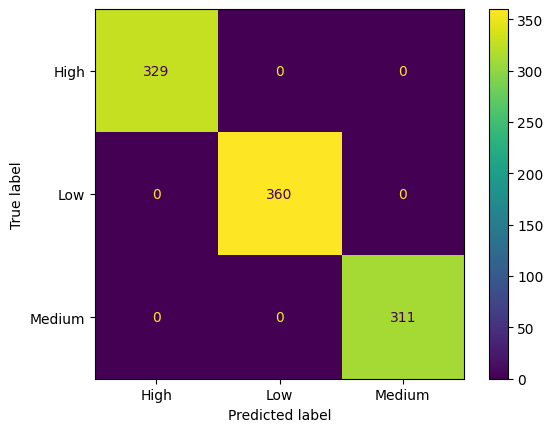

In [79]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=pipeline.named_steps["model"].classes_
)

plt.show()

In [80]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

        High       1.00      1.00      1.00       329
         Low       1.00      1.00      1.00       360
      Medium       1.00      1.00      1.00       311

    accuracy                           1.00      1000
   macro avg       1.00      1.00      1.00      1000
weighted avg       1.00      1.00      1.00      1000

